# 20 — GNN-SDM Architecture Search

Test different GraphSAGE architectures on 6 representative species
to find the best depth/width for Swiss flora before the full run.

**Key species** (covering diverse habitats):
- *Picea abies* — montane forest
- *Fagus sylvatica* — lowland forest
- *Trifolium pratense* — grassland/meadow
- *Potentilla erecta* — alpine/subalpine grassland
- *Phragmites australis* — wetland
- *Senecio inaequidens* — invasive/urban

### Setup and load graph

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import json
import time
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import networkx as nx

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Load graph
with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

# Load patch features and names
patch_features = np.load('patch_features.npy')
with open('patch_feature_names.json') as f:
    feature_names = json.load(f)

n_patches = G.number_of_nodes()
n_features = len(feature_names)
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges, '
      f'{n_features} features')


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: Tesla T4
Graph: 166,464 nodes, 465,833 edges, 12 features


### Convert to PyG Data object

In [2]:
# Node features
X = torch.tensor(patch_features, dtype=torch.float32)

# Normalize features (zero mean, unit variance)
X_mean = X.mean(dim=0)
X_std = X.std(dim=0).clamp(min=1e-6)
X = (X - X_mean) / X_std

# Edge index (PyG format: 2 × n_edges, both directions for undirected)
edges = list(G.edges())
src = [e[0] for e in edges] + [e[1] for e in edges]
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)

# PageRank for presence weighting
print('Computing PageRank...')
pagerank = nx.pagerank(G)
pr_values = torch.tensor([pagerank[i] for i in range(n_patches)], dtype=torch.float32)

print(f'Node features: {X.shape}')
print(f'Edge index: {edge_index.shape}')
print(f'PageRank: min={pr_values.min():.6f}, max={pr_values.max():.6f}')


Computing PageRank...
Node features: torch.Size([166464, 12])
Edge index: torch.Size([2, 931666])
PageRank: min=0.000002, max=0.001098


### Load GBIF and map to patches

In [3]:
import rioxarray
from s3_utils import load_zarr
from rasterio.transform import rowcol

# Patch labels raster for coordinate mapping
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
transform = patch_labels_da.rio.transform()

# GBIF
gbif = pd.read_parquet(config.GBIF_PARQUET, storage_options={'anon': False})

# Vectorized mapping: all records → patch IDs
rows, cols = rowcol(transform, gbif['decimallongitude'].values,
                    gbif['decimallatitude'].values)
rows, cols = np.array(rows), np.array(cols)
h, w = patch_labels.shape
valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
gbif_patch_ids = np.full(len(gbif), -1, dtype=np.int32)
gbif_patch_ids[valid] = patch_labels[rows[valid], cols[valid]]
gbif['patch_id'] = gbif_patch_ids

# Group by species
MIN_RECORDS = 100
species_counts = gbif['species'].value_counts()
species_patch_groups = (
    gbif[gbif['patch_id'] >= 0]
    .groupby('species')['patch_id']
    .unique()
)
species_patches = {
    sp: set(patches)
    for sp, patches in species_patch_groups.items()
    if species_counts.get(sp, 0) >= MIN_RECORDS
}

print(f'Species with >= {MIN_RECORDS} records: {len(species_patches):,}')

# Free the raster
del patch_labels, patch_labels_da
import gc; gc.collect()


Species with >= 100 records: 3,756


10491

### GNN-SDM Model (flexible architecture)

Configurable number of GraphSAGE layers and hidden dimensions.
The paper used [24, 18, 8] but we'll test alternatives for flora.

In [4]:
class GNNSDM(torch.nn.Module):
    def __init__(self, in_channels, hidden_dims=[24, 18, 8], dropout=0.2):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.dropout = dropout

        prev = in_channels
        for dim in hidden_dims:
            self.convs.append(SAGEConv(prev, dim, aggr='mean'))
            prev = dim

        self.out = torch.nn.Linear(prev, 1)

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = F.leaky_relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return torch.sigmoid(self.out(x)).squeeze(-1)

# Test
m = GNNSDM(n_features, [24, 18, 8])
print(m)
print(f'Parameters: {sum(p.numel() for p in m.parameters()):,}')


GNNSDM(
  (convs): ModuleList(
    (0): SAGEConv(12, 24, aggr=mean)
    (1): SAGEConv(24, 18, aggr=mean)
    (2): SAGEConv(18, 8, aggr=mean)
  )
  (out): Linear(in_features=8, out_features=1, bias=True)
)
Parameters: 1,787


### Training function

Per-species training: label presence patches, select background via
One-Class SVM, weight presence by PageRank, train with MSE loss.

In [5]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score


def train_gnn_species(species_name, presence_patches, X, edge_index,
                      pr_values, n_patches, device,
                      hidden_dims=[24, 18, 8], epochs=500, lr=0.001,
                      patience=50, return_history=False):
    """
    Train GNN-SDM for one species with early stopping.
    Stops if val AUC doesn't improve for `patience` epochs.
    Returns: (suitability, best_val_auc) or (suitability, best_val_auc, history)
    """
    presence = np.array(list(presence_patches))
    n_pres = len(presence)

    X_np = X.cpu().numpy()
    oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
    oc_svm.fit(X_np[presence])

    non_presence = np.setdiff1d(np.arange(n_patches), presence)
    scores = oc_svm.decision_function(X_np[non_presence])
    n_bg = min(len(non_presence), n_pres * 2)
    bg_idx = non_presence[np.argsort(scores)[:n_bg]]

    labels = torch.zeros(n_patches, dtype=torch.float32)
    labels[presence] = 1.0
    weights = torch.zeros(n_patches, dtype=torch.float32)
    weights[presence] = pr_values[presence]
    weights[presence] = weights[presence] / weights[presence].sum() * n_pres
    weights[bg_idx] = 1.0

    labelled = np.concatenate([presence, bg_idx])
    rng = np.random.default_rng(42)
    rng.shuffle(labelled)
    split = int(0.8 * len(labelled))
    train_mask = torch.zeros(n_patches, dtype=torch.bool, device=device)
    val_mask = torch.zeros(n_patches, dtype=torch.bool, device=device)
    train_mask[labelled[:split]] = True
    val_mask[labelled[split:]] = True

    labels = labels.to(device)
    weights = weights.to(device)

    model = GNNSDM(X.shape[1], hidden_dims).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_auc = 0.0
    best_state = None
    epochs_no_improve = 0
    history = [] if return_history else None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X, edge_index)
        loss = (weights[train_mask] * (pred[train_mask] - labels[train_mask]) ** 2).mean()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                pred_all = model(X, edge_index)
                val_pred = pred_all[val_mask].cpu().numpy()
                val_labels = labels[val_mask].cpu().numpy()
                train_loss = loss.item()

            val_auc = 0.0
            if len(np.unique(val_labels)) == 2:
                val_auc = roc_auc_score(val_labels, val_pred)
                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 10

            if return_history:
                val_loss = (weights[val_mask] * (pred_all[val_mask] - labels[val_mask]) ** 2).mean().item()
                history.append({'epoch': epoch + 1, 'train_loss': train_loss,
                                'val_loss': val_loss, 'val_auc': val_auc})

            # Early stopping
            if epochs_no_improve >= patience:
                break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        suitability = model(X, edge_index).cpu().numpy()

    if return_history:
        return suitability, best_val_auc, history
    return suitability, best_val_auc

print('Training function defined (with early stopping).')


Training function defined (with early stopping).


### Architecture search on key species

Test different GraphSAGE depths and widths on 6 representative species
to find the best architecture for Swiss flora before the full run.

In [6]:
KEY_SPECIES = [
    'Picea abies', 'Fagus sylvatica', 'Trifolium pratense',
    'Potentilla erecta', 'Phragmites australis', 'Senecio inaequidens',
]

ARCHITECTURES = {
    '1-layer [16]':       [16],
    '2-layer [24,12]':    [24, 12],
    'paper [24,18,8]':    [24, 18, 8],
    'wider [48,32,16]':   [48, 32, 16],
    'extra-wide [64,48,32]': [64, 48, 32],
    '4-layer [32,24,16,8]': [32, 24, 16, 8],
}

X_gpu = X.to(device)
edge_index_gpu = edge_index.to(device)

arch_results = []
all_histories = {}  # (arch, species) → history

for arch_name, hidden_dims in ARCHITECTURES.items():
    n_params = sum(p.numel() for p in GNNSDM(n_features, hidden_dims).parameters())
    print(f'\n--- {arch_name} ({n_params:,} params) ---')

    for sp in KEY_SPECIES:
        if sp not in species_patches or len(species_patches[sp]) < 5:
            continue

        t0 = time.time()
        suit, val_auc, hist = train_gnn_species(
            sp, species_patches[sp], X_gpu, edge_index_gpu,
            pr_values, n_patches, device,
            hidden_dims=hidden_dims, epochs=500, return_history=True,
        )
        dt = time.time() - t0

        arch_results.append({
            'architecture': arch_name,
            'species': sp,
            'val_auc': val_auc,
            'train_time': dt,
        })
        all_histories[(arch_name, sp)] = hist
        print(f'  {sp:30s}  AUC={val_auc:.3f}  ({dt:.1f}s)')

arch_df = pd.DataFrame(arch_results)
print('\nDone.')



--- 1-layer [16] (417 params) ---
  Picea abies                     AUC=0.953  (9.2s)
  Fagus sylvatica                 AUC=0.974  (15.3s)
  Trifolium pratense              AUC=0.940  (8.6s)
  Potentilla erecta               AUC=0.949  (7.0s)
  Phragmites australis            AUC=0.990  (5.3s)
  Senecio inaequidens             AUC=0.998  (6.2s)

--- 2-layer [24,12] (1,201 params) ---
  Picea abies                     AUC=0.978  (11.8s)
  Fagus sylvatica                 AUC=0.983  (18.4s)
  Trifolium pratense              AUC=0.964  (11.7s)
  Potentilla erecta               AUC=0.974  (10.0s)
  Phragmites australis            AUC=0.994  (8.3s)
  Senecio inaequidens             AUC=0.998  (9.2s)

--- paper [24,18,8] (1,787 params) ---
  Picea abies                     AUC=0.976  (14.2s)
  Fagus sylvatica                 AUC=0.990  (20.7s)
  Trifolium pratense              AUC=0.968  (14.0s)
  Potentilla erecta               AUC=0.975  (12.3s)
  Phragmites australis            AUC=0.997 

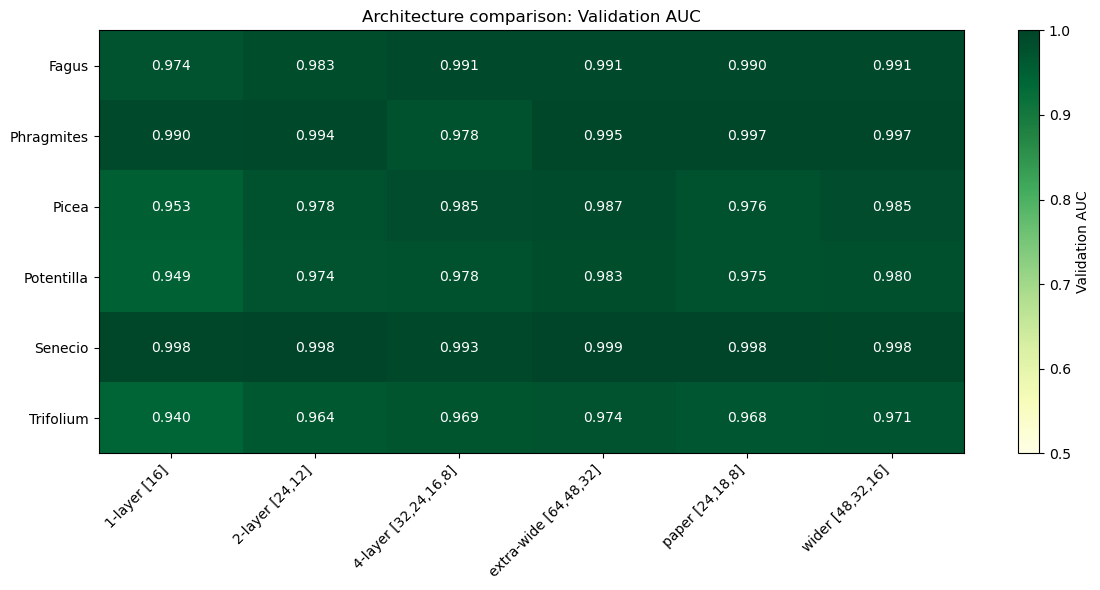

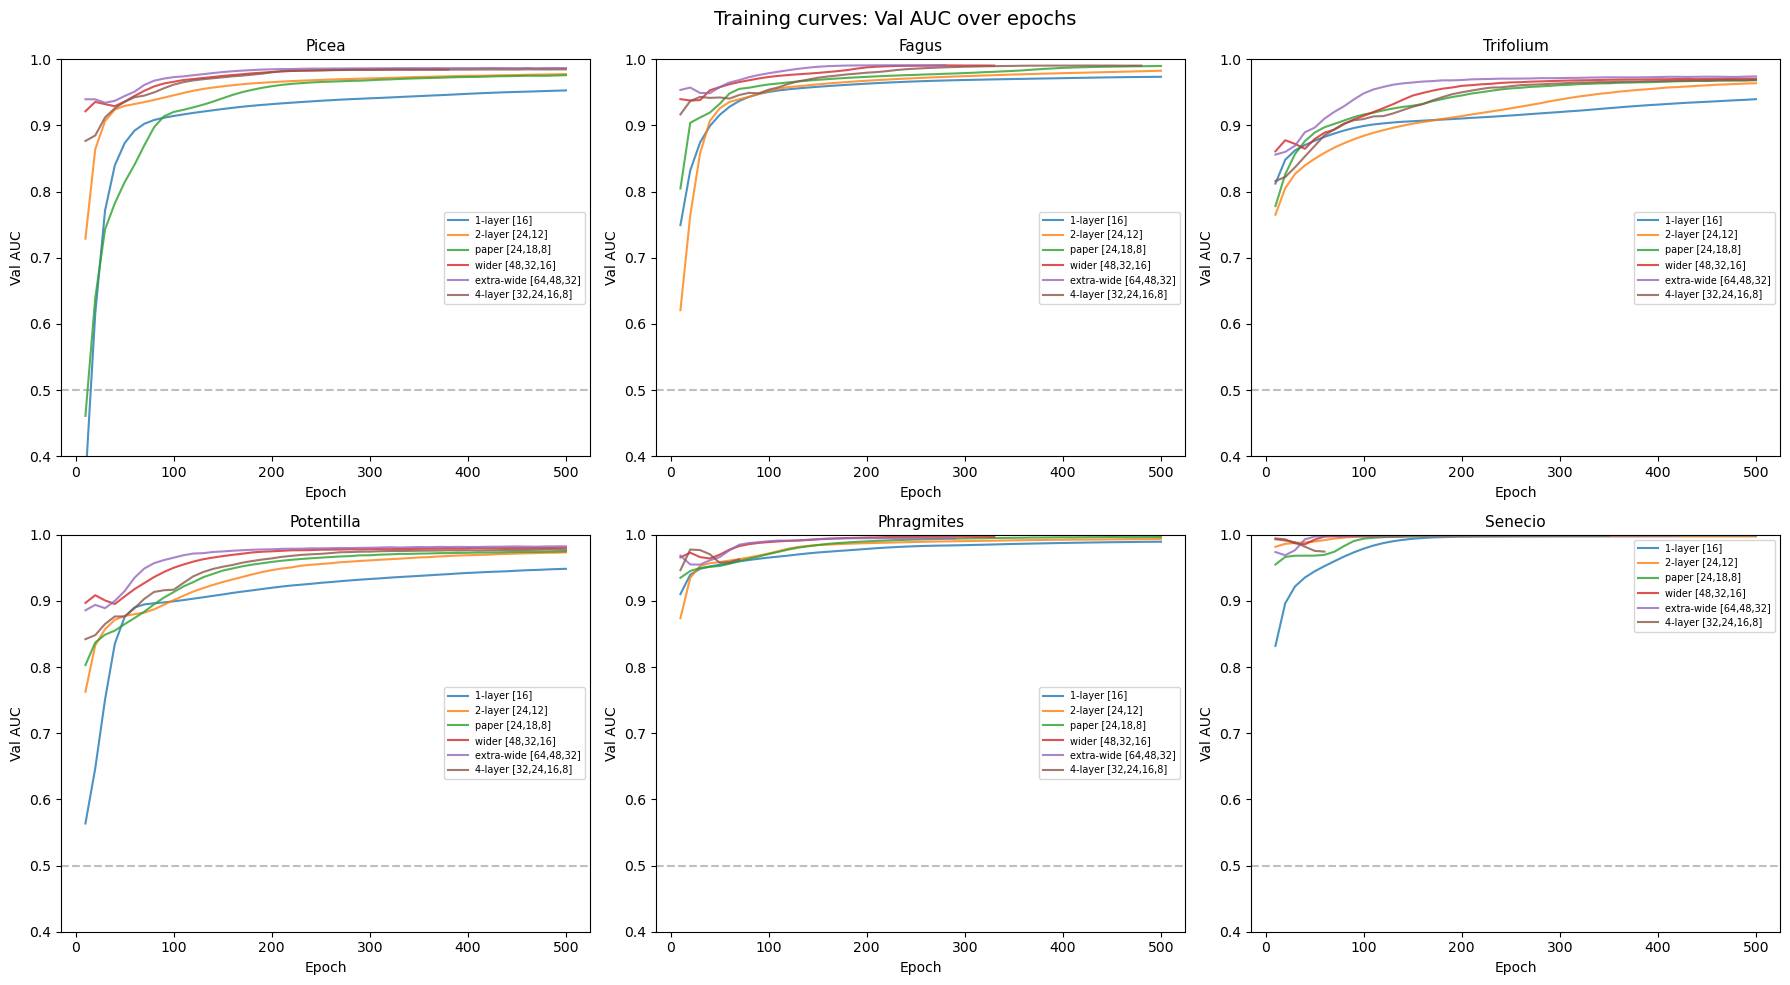

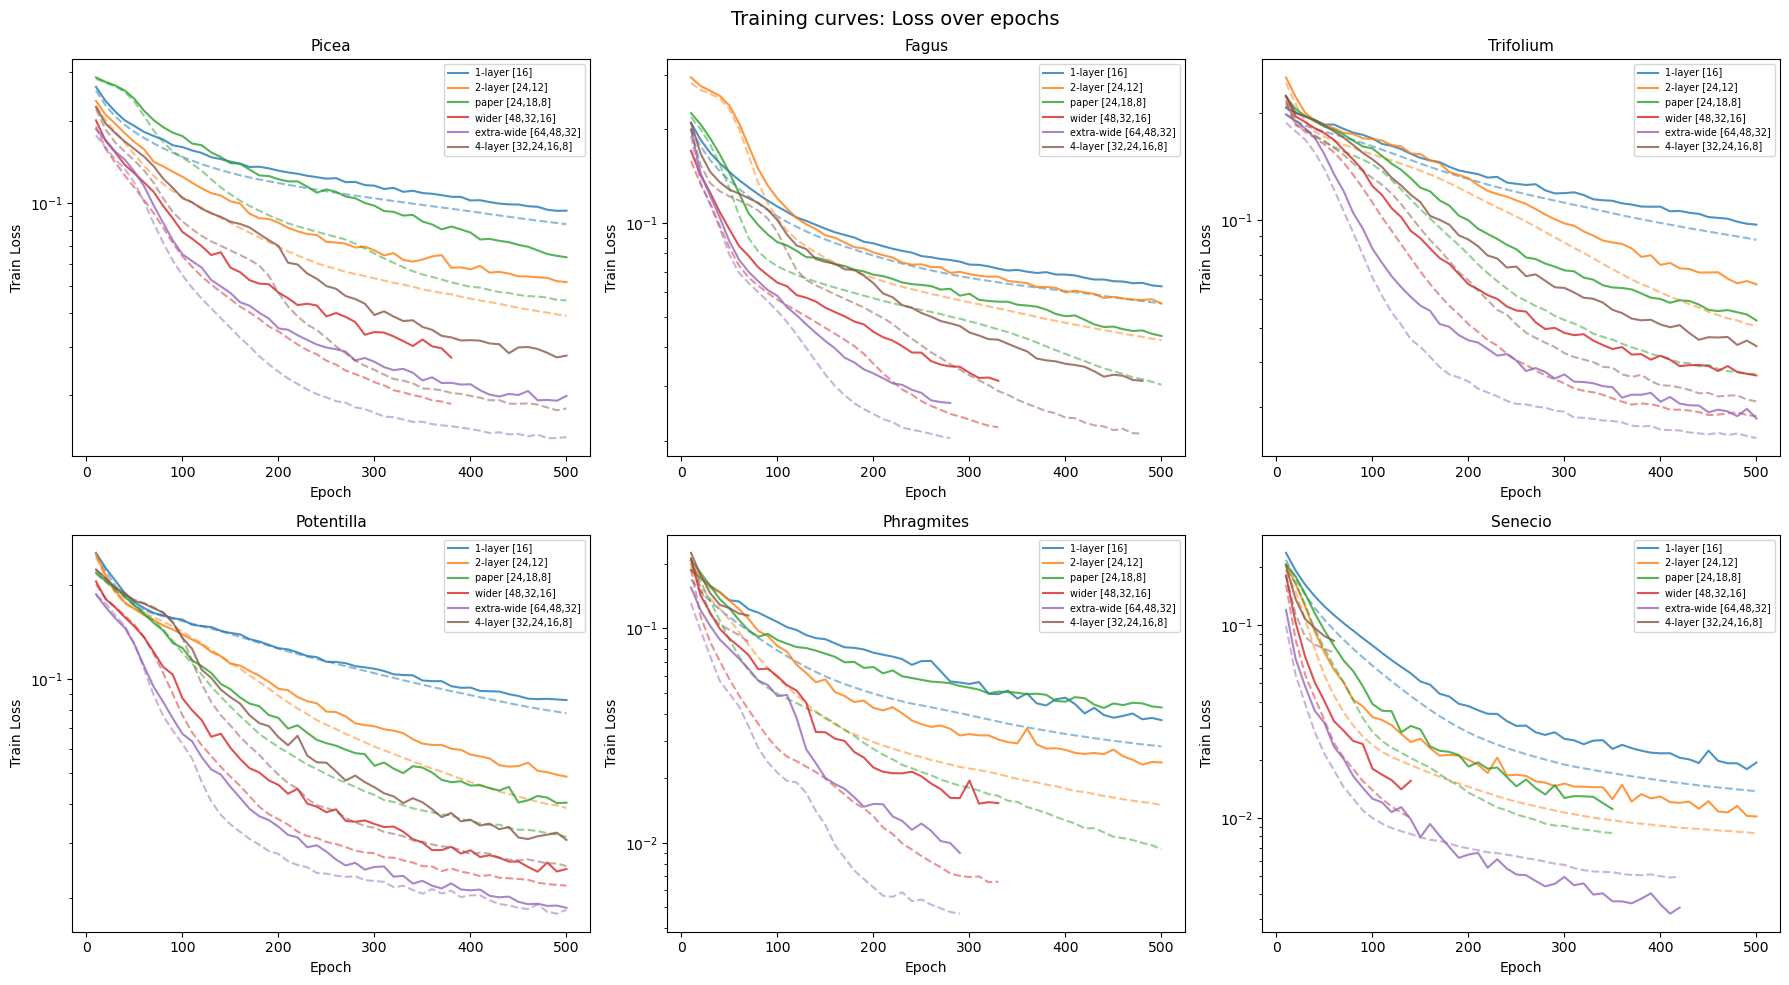

Mean AUC by architecture:
  extra-wide [64,48,32]      0.9881
  wider [48,32,16]           0.9870
  paper [24,18,8]            0.9840
  4-layer [32,24,16,8]       0.9822
  2-layer [24,12]            0.9816
  1-layer [16]               0.9671

Best: extra-wide [64,48,32] → hidden_dims=[64, 48, 32]


In [7]:
import matplotlib.pyplot as plt

# --- 1. AUC heatmap ---
pivot = arch_df.pivot(index='species', columns='architecture', values='val_auc')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([s.split()[0] for s in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if val > 0.8 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10, color=color)
plt.colorbar(im, label='Validation AUC')
ax.set_title('Architecture comparison: Validation AUC')
plt.tight_layout()
plt.show()

# --- 2. Training curves ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, sp in zip(axes.flat, KEY_SPECIES):
    for arch_name in ARCHITECTURES:
        hist = all_histories.get((arch_name, sp))
        if hist:
            epochs = [h['epoch'] for h in hist]
            aucs = [h['val_auc'] for h in hist]
            ax.plot(epochs, aucs, label=arch_name, alpha=0.8)
    ax.set_title(sp.split()[0], fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val AUC')
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
    ax.legend(fontsize=7)
plt.suptitle('Training curves: Val AUC over epochs', fontsize=14)
plt.tight_layout()
plt.show()

# --- 3. Loss curves ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, sp in zip(axes.flat, KEY_SPECIES):
    for arch_name in ARCHITECTURES:
        hist = all_histories.get((arch_name, sp))
        if hist:
            epochs = [h['epoch'] for h in hist]
            losses = [h['train_loss'] for h in hist]
            ax.plot(epochs, losses, label=arch_name, alpha=0.8)
            val_losses = [h.get('val_loss', 0) for h in hist]
            ax.plot(epochs, val_losses, linestyle='--', alpha=0.5, color=ax.get_lines()[-1].get_color())
    ax.set_title(sp.split()[0], fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
plt.suptitle('Training curves: Loss over epochs', fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. Best architecture ---
mean_auc = arch_df.groupby('architecture')['val_auc'].mean().sort_values(ascending=False)
print('Mean AUC by architecture:')
for arch, auc in mean_auc.items():
    print(f'  {arch:25s}  {auc:.4f}')

best_arch_name = mean_auc.index[0]
best_hidden_dims = ARCHITECTURES[best_arch_name]
print(f'\nBest: {best_arch_name} → hidden_dims={best_hidden_dims}')
